In [1]:
import numpy as np
import pandas as pd
from scapy.all import rdpcap, raw
import matplotlib.pyplot as plt
import seaborn as sns



𝗔𝘁𝘂𝗿 𝗝𝗮𝗹𝘂𝗿 𝗣𝗮𝗸𝗲𝘁 𝗱𝗮𝗻 𝗽𝗮𝗻𝗴𝗴𝗶𝗹 𝗱𝗮𝘁𝗮𝘀𝗲𝘁

In [2]:
# Memamnggil data
# TRAIN_PCAP_PATH = training.pcap
# TRAIN_LBELS_PATH = label(y) train

# TEST_PCAP_PATH = test.pcap
# TEST_LABELS_PATH = label(y) test

# --- KONFIGURASI DAN PATH FILE ---
BASE_PATH = '/home/dani/Documents/tugas akhir/TugasAkhir/DataTugasAkhirku2026/dataTOWIDSmentah/'
TRAIN_PCAP_PATH = BASE_PATH + 'Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap'
TRAIN_LABELS_PATH = BASE_PATH + 'y_train.csv'

# Kita definisikan juga path untuk data testing untuk nanti
TEST_PCAP_PATH = BASE_PATH + 'Automotive_Ethernet_with_Attack_original_10_17_20_04_test.pcap'
TEST_LABELS_PATH = BASE_PATH + 'y_test.csv'

print("Langkah 1 Selesai: Library dan path sudah siap.")

Langkah 1 Selesai: Library dan path sudah siap.


𝗕𝘂𝗮𝘁 𝗙𝘂𝗻𝗴𝘀𝗶 𝗘𝗸𝘀𝘁𝗿𝗮𝗸 𝗣𝗮𝗸𝗲𝘁 𝗱𝗮𝗻 𝗕𝘂𝗶𝗹 𝗪𝗶𝗻𝗱𝗼𝘄

In [3]:
# fungsi untuk ekstrak paket dari file pcap dengan panjang tetap 64 byte
Nbyte=64
def extract_packets(pcap_path, n_bytes=Nbyte):
    packets = rdpcap(pcap_path)
    data = []

    for pkt in packets:
        pkt_bytes = raw(pkt)

        if len(pkt_bytes) < n_bytes:
            pkt_bytes = pkt_bytes + bytes(n_bytes - len(pkt_bytes))  # zero padding
        else:
            pkt_bytes = pkt_bytes[:n_bytes]  # truncate

        data.append(np.frombuffer(pkt_bytes, dtype=np.uint8))

    return np.array(data)  # (num_packets, 64)


In [4]:
# fungsi untuk membangun window dari data paket

def build_windows(X_pkt, y_pkt, N=Nbyte, step=Nbyte):
    X_win, y_win = [], []

    for i in range(0, len(X_pkt) - N + 1, step):
        window_data = X_pkt[i:i+N]      # shape: (N, M)
        window_label = y_pkt[i:i+N]

        X_win.append(window_data)  
        y_win.append(1 if np.any(window_label == 1) else 0)

    return np.array(X_win), np.array(y_win)


𝗣𝗿𝗼𝘀𝗲𝘀 𝗧𝗿𝗮𝗶𝗻 𝗕𝗶𝗻𝗮𝗿𝘆 𝗖𝗹𝗮𝘀𝘀 𝗱𝗮𝗿𝗶 𝗘𝗸𝘀𝘁𝗿𝗮𝗸 𝗛𝗶𝗻𝗴𝗴𝗮 𝗕𝘂𝗶𝗹𝗱 𝗪𝗶𝗻𝗱𝗼𝘄

In [5]:
# Pengecekkan Data dulu
# data train di masukkan ke variabel df_labels_train
# lalu kolom 2 yang berisi binary class di masukkn ke variabel labels_train1

# --- MEMUAT LABEL TRAINING ---
print("Memuat file label dari:", TRAIN_LABELS_PATH)
df_labels_train = pd.read_csv(TRAIN_LABELS_PATH , header=None)

# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_train1 = df_labels_train.iloc[:, 1].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_train1)} label.")
print("Contoh 5 label pertama:", labels_train1[:5])
print("Distribusi Label:")
print(df_labels_train.iloc[:, 1].value_counts())

Memuat file label dari: /home/dani/Documents/tugas akhir/TugasAkhir/DataTugasAkhirku2026/dataTOWIDSmentah/y_train.csv

Berhasil memuat 1203737 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
1
Normal      954912
Abnormal    248825
Name: count, dtype: int64


In [6]:
# kalau sebelumnya kolom 1, sekarang kolom 2 yang berisi multi class di masukkn ke variabel labels_train2

# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_train2 = df_labels_train.iloc[:, 2].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_train2)} label.")
print("Contoh 5 label pertama:", labels_train2[:5])
print("Distribusi Label:")
print(df_labels_train.iloc[:, 2].value_counts())


Berhasil memuat 1203737 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
2
Normal    954912
C_D        85466
P_I        64635
F_I        35112
M_F        33765
C_R        29847
Name: count, dtype: int64


In [7]:
# proses train pcap ke fungsi ekstrak paket
x_pkt_train=extract_packets(TRAIN_PCAP_PATH)

In [8]:
# sekarang kita ambil labelnya dari variabel df_labels_train tadi saat kita memunculkannya.
binary_labels_text   = df_labels_train.iloc[:, 1]
y_label_train  = binary_labels_text.map({'Normal': 0, 'Abnormal': 1}).values

In [9]:
from sklearn.model_selection import train_test_split

# split 70:30
X_train, X_eval, y_train, y_eval = train_test_split(
    x_pkt_train,
    y_label_train,
    test_size=0.30,
    shuffle=False
)

In [10]:
# cek informasi hasil ekstrak paket dan contoh data pertama
print(type(X_train))
print(X_train.shape)
print(X_train.dtype)
X_train[0]

<class 'numpy.ndarray'>
(842615, 64)
uint8


array([145, 239,   0,   0, 254,   0,   0, 252, 112,   0,   0,   3, 129,
         0,   0,   2,  34, 240,   0, 136,  22,   0,   1,  35,  69, 103,
       137, 171, 205, 239,   0,   0,   0,   0,   0,   0,   0,   0,   1,
       136,  95, 160,  63,   6, 196,  96, 160,   0,   0,   0,  45, 145,
       232, 183,  71,  64,  65,  16,   0,   0,   1, 224,  15, 174],
      dtype=uint8)

In [11]:
# cek informasi hasil ekstrak paket dan contoh data pertama
print(type(X_eval))
print(X_eval.shape)
print(X_eval.dtype)
X_eval[0]

<class 'numpy.ndarray'>
(361122, 64)
uint8


array([220, 166,  50,  94,  72,  71, 220, 166,  50,  93, 206, 210,   8,
         0,  69,   0,   0,  37, 144, 146,  64,   0,  64,  17,  20, 224,
       192, 168,  10,   2, 192, 168,  10,   3, 199,  56, 234, 102,   0,
        17,  87, 153,   8,   0,   0,   0,   0,  18,   0,  43,  89,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
      dtype=uint8)

In [12]:
# bukti zero padding berhasil, dimana paket yang kurang panjang di isi dengan 0 pada bagian akhir
X_eval[7][-16:]


array([177, 124,  89,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0], dtype=uint8)

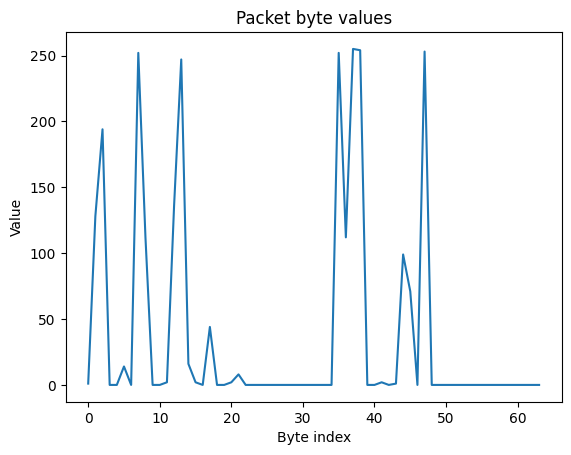

In [13]:
# Visualisasi salah satu paket byte values terutama yang sudah di zero padding
import matplotlib.pyplot as plt

plt.plot(X_train[7])
plt.title("Packet byte values")
plt.xlabel("Byte index")
plt.ylabel("Value")
plt.show()


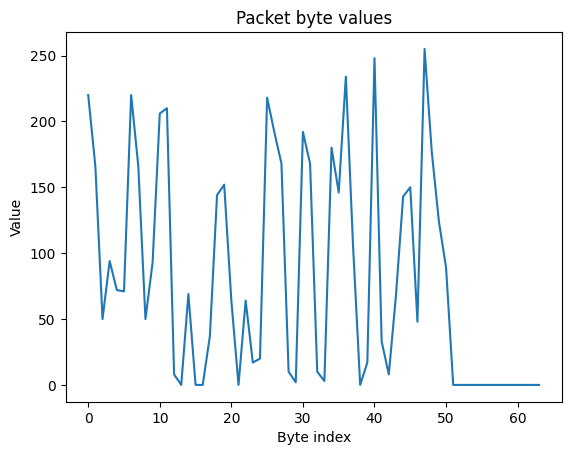

In [14]:
# Visualisasi salah satu paket byte values terutama yang sudah di zero padding
import matplotlib.pyplot as plt

plt.plot(X_eval[7])
plt.title("Packet byte values")
plt.xlabel("Byte index")
plt.ylabel("Value")
plt.show()


In [15]:
# Eksekusi fungsi build_windows dengan masukkan data paket dan labelnya
x_seq_train, y_seq_train = build_windows(X_train, y_train)

In [16]:
# Periksa hasilnya, dimana didapat sekitar 1.2 juta window denan panjang 64 paket per window dan panjang paket 64 byte
x_seq_train.shape, y_seq_train.shape, np.unique(y_seq_train)

((13165, 64, 64), (13165,), array([0, 1]))

In [17]:
# Eksekusi fungsi build_windows dengan masukkan data paket dan labelnya
x_seq_eval, y_seq_eval = build_windows(X_eval, y_eval)

In [18]:
# Periksa hasilnya, dimana didapat sekitar 1.2 juta window denan panjang 64 paket per window dan panjang paket 64 byte
x_seq_eval.shape, y_seq_eval.shape, np.unique(y_seq_eval)

((5642, 64, 64), (5642,), array([0, 1]))

In [19]:
import os
import numpy as np

SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/"
train_path = os.path.join(SAVE_DIR, "tow_ids_train_windows.npz")

np.savez(train_path, X=x_seq_train, y=y_seq_train)

print("File train berhasil disimpan di:")
print(train_path)

del train_path, x_seq_train, y_seq_train

SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/"
eval_path = os.path.join(SAVE_DIR, "tow_ids_eval_windows.npz")

np.savez(eval_path, X=x_seq_eval, y=y_seq_eval)

print("File eval berhasil disimpan di:")
print(eval_path)

del eval_path, x_seq_eval, y_seq_eval

File train berhasil disimpan di:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/tow_ids_train_windows.npz
File eval berhasil disimpan di:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/tow_ids_eval_windows.npz


𝗣𝗿𝗼𝘀𝗲𝘀 𝗧𝗲𝘀𝘁 𝗕𝗶𝗻𝗮𝗿𝘆 𝗖𝗹𝗮𝘀𝘀 𝗱𝗮𝗿𝗶 𝗘𝗸𝘀𝘁𝗿𝗮𝗸 𝗛𝗶𝗻𝗴𝗴𝗮 𝗕𝘂𝗶𝗹𝗱 𝗪𝗶𝗻𝗱𝗼𝘄

In [20]:
# Periksa Data dulu
# data test di masukkan ke variabel df_labels_test
# --- MEMUAT LABEL Testing ---
print("Memuat file label dari:", TEST_LABELS_PATH)
df_labels_test = pd.read_csv(TEST_LABELS_PATH , header=None)

# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_test1 = df_labels_test.iloc[:, 1].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_test1)} label.")
print("Contoh 5 label pertama:", labels_test1[:5])
print("Distribusi Label:")
print(df_labels_test.iloc[:, 1].value_counts())
print(df_labels_test.head())


Memuat file label dari: /home/dani/Documents/tugas akhir/TugasAkhir/DataTugasAkhirku2026/dataTOWIDSmentah/y_test.csv

Berhasil memuat 791611 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
1
Normal      660777
Abnormal    130834
Name: count, dtype: int64
   0       1       2
0  1  Normal  Normal
1  2  Normal  Normal
2  3  Normal  Normal
3  4  Normal  Normal
4  5  Normal  Normal


In [21]:
# sekarang cek kolom 2 yang berisi multi class di masukkn ke variabel labels_test2
# Mengambil semua nilai dari kolom pertama dan menyimpannya sebagai array numpy
labels_test2 = df_labels_test.iloc[:, 2].values

# --- MEMERIKSA LABEL ---
print(f"\nBerhasil memuat {len(labels_test2)} label.")
print("Contoh 5 label pertama:", labels_test2[:5])
print("Distribusi Label:")
print(df_labels_test.iloc[:, 2].value_counts())


Berhasil memuat 791611 label.
Contoh 5 label pertama: ['Normal' 'Normal' 'Normal' 'Normal' 'Normal']
Distribusi Label:
2
Normal    660777
C_D        41203
C_R        29847
P_I        26013
F_I        16962
M_F        16809
Name: count, dtype: int64


In [22]:
# proses test pcap ke fungsi ekstrak paket
x_pkt_test=extract_packets(TEST_PCAP_PATH)

In [23]:
# cek informasi hasil ekstrak paket test dan contoh data pertama
print(type(x_pkt_test))
print(x_pkt_test.shape)
print(x_pkt_test.dtype)
x_pkt_test[0]

<class 'numpy.ndarray'>
(791611, 64)
uint8


array([145, 239,   0,   0, 254,   0,   0, 252, 112,   0,   0,   3, 129,
         0,   0,   2,  34, 240,   0, 136,   3,   0,   1,  35,  69, 103,
       137, 171, 205, 239,   0,   0,   0,   0,   0,   0,   0,   0,   1,
       136,  95, 160,  63,   6, 196,  96, 160,   0,   0,   0, 166, 118,
       108,  19,  71,  64,  66,  48, 158,   0, 255, 255, 255, 255],
      dtype=uint8)

In [24]:
# bukti zero padding berhasil, dimana paket yang kurang panjang di isi dengan 0 pada bagian akhir
x_pkt_test[23][-16:]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8)

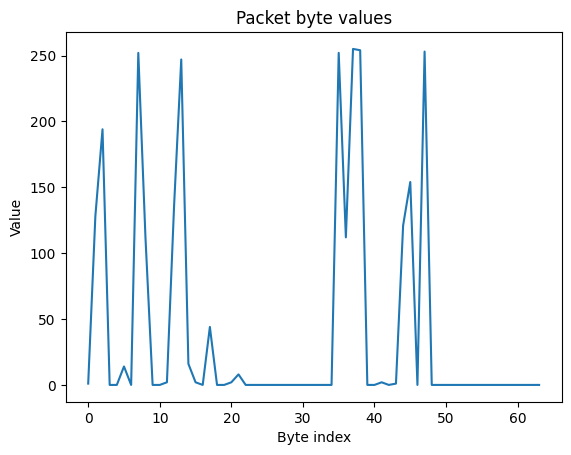

In [25]:
# Visualisasi salah satu paket byte values terutama yang sudah di zero padding
import matplotlib.pyplot as plt

plt.plot(x_pkt_test[23])
plt.title("Packet byte values")
plt.xlabel("Byte index")
plt.ylabel("Value")
plt.show()


In [26]:
# disini kita ambil labelnya(binaryclass) dari variabel df_labels_test tadi saat kita memunculkannya.
binary_labels_text   = df_labels_test.iloc[:, 1]
y_label_test = binary_labels_text.map({'Normal': 0, 'Abnormal': 1}).values

In [27]:
# masukkan ke fungsi build_windows dengan masukkan data paket dan labelnya
x_seq_test, y_seq_test = build_windows(x_pkt_test, y_label_test)
x_seq_test.shape, y_seq_test.shape

((12368, 64, 64), (12368,))

In [28]:
# Periksa hasilnya, dimana didapat sekitar 1.2 juta window denan panjang 64 paket per window dan panjang paket 64 byte
x_seq_test.shape, y_seq_test.shape, np.unique(y_seq_test)

((12368, 64, 64), (12368,), array([0, 1]))

In [29]:
import os
import numpy as np

SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/"
test_path  = os.path.join(SAVE_DIR, "tow_ids_test_windows.npz")

# simpan file
np.savez(test_path,  X=x_seq_test,  y=y_seq_test)

print("File berhasil disimpan di:")
print(test_path)

del test_path, x_seq_test, y_seq_test

File berhasil disimpan di:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/tow_ids_test_windows.npz


𝗡𝗼𝗿𝗺𝗮𝗹𝗶𝘀𝗮𝘀𝗶 𝗗𝗮𝘁𝗮 𝗪𝗶𝗻𝗱𝗼𝘄

In [30]:
def normalize_minmax(X):
    return X.astype(np.float32) / 255.0



𝗟𝗼𝗮𝗱 Train untuk 𝗡𝗼𝗿𝗺𝗮𝗹𝗶𝘀𝗮𝘀𝗶

In [31]:
import os
import numpy as np
Loader = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/"
SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/"
train_path = os.path.join(Loader, "tow_ids_train_windows.npz")
eval_path = os.path.join(Loader, "tow_ids_eval_windows.npz")
# load
train_data = np.load(train_path)
eval_data = np.load(eval_path)

x_seq_train = train_data["X"]
y_seq_train = train_data["y"]
x_seq_eval = eval_data["X"]
y_seq_eval = eval_data["y"]



Pengecekkan setelah load

In [32]:
print("=== TRAIN ===")
print("X_train shape :", x_seq_train.shape)
print("y_train shape :", y_seq_train.shape)
print("X_train dtype :", x_seq_train.dtype)
print("y_train dtype :", y_seq_train.dtype)


print("=== EVAL ===")
print("X_eval shape :", x_seq_eval.shape)
print("y_eval shape :", y_seq_eval.shape)
print("X_eval dtype :", x_seq_eval.dtype)
print("y_eval dtype :", y_seq_eval.dtype)


=== TRAIN ===
X_train shape : (13165, 64, 64)
y_train shape : (13165,)
X_train dtype : uint8
y_train dtype : int64
=== EVAL ===
X_eval shape : (5642, 64, 64)
y_eval shape : (5642,)
X_eval dtype : uint8
y_eval dtype : int64


In [33]:
assert x_seq_train.shape[0] == y_seq_train.shape[0], "Train mismatch!"
print("Sample count konsisten.")


Sample count konsisten.


In [34]:
assert x_seq_eval.shape[0] == y_seq_eval.shape[0], "Eval mismatch!"
print("Sample count konsisten.")


Sample count konsisten.


In [35]:
print("Train min:", x_seq_train.min())
print("Train max:", x_seq_train.max())
print("Train mean:", x_seq_train.mean())

print("Eval min:", x_seq_eval.min())
print("Eval max:", x_seq_eval.max())
print("Eval mean:", x_seq_eval.mean())


Train min: 0
Train max: 255
Train mean: 70.68161961388506
Eval min: 0
Eval max: 255
Eval mean: 67.29518730544909


In [36]:
x_train_norm = normalize_minmax(x_seq_train)
train_out = os.path.join(SAVE_DIR, "tow_ids_train_windows_norm.npz")
np.savez(train_out, X=x_train_norm, y=y_seq_train)
print("Saved normalis:")
print(train_out)

x_eval_norm = normalize_minmax(x_seq_eval)
eval_out = os.path.join(SAVE_DIR, "tow_ids_eval_windows_norm.npz")
np.savez(eval_out, X=x_eval_norm, y=y_seq_eval)
print("Saved normalis:")
print(eval_out)

Saved normalis:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/tow_ids_train_windows_norm.npz
Saved normalis:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/tow_ids_eval_windows_norm.npz


In [37]:
print("Train min:", x_train_norm.min())
print("Train max:", x_train_norm.max())
print("Train mean:", x_train_norm.mean())

print("Eval min:", x_eval_norm.min())
print("Eval max:", x_eval_norm.max())
print("Eval mean:", x_eval_norm.mean())


Train min: 0.0
Train max: 1.0
Train mean: 0.27718326
Eval min: 0.0
Eval max: 1.0
Eval mean: 0.26390234


In [38]:
print("=== TRAIN ===")
print("X_train shape :", x_train_norm.shape)
print("y_train shape :", y_seq_train.shape)
print("X_train dtype :", x_train_norm.dtype)
print("y_train dtype :", y_seq_train.dtype)

print("Train min:", x_train_norm.min())
print("Train max:", x_train_norm.max())
print("Train mean:", x_train_norm.mean())

del x_train_norm, y_seq_train, train_out


print("=== EVAL ===")
print("X_eval shape :", x_eval_norm.shape)
print("y_eval shape :", y_seq_eval.shape)
print("X_eval dtype :", x_eval_norm.dtype)
print("y_eval dtype :", y_seq_eval.dtype)
print("Eval min:", x_eval_norm.min())
print("Eval max:", x_eval_norm.max())
print("Eval mean:", x_eval_norm.mean())

del x_eval_norm, y_seq_eval, eval_out

=== TRAIN ===
X_train shape : (13165, 64, 64)
y_train shape : (13165,)
X_train dtype : float32
y_train dtype : int64
Train min: 0.0
Train max: 1.0
Train mean: 0.27718326
=== EVAL ===
X_eval shape : (5642, 64, 64)
y_eval shape : (5642,)
X_eval dtype : float32
y_eval dtype : int64
Eval min: 0.0
Eval max: 1.0
Eval mean: 0.26390234


In [39]:
import os
import numpy as np
test_path  = os.path.join(Loader, "tow_ids_test_windows.npz")
# load
test_data  = np.load(test_path)

x_seq_test  = test_data["X"]
y_seq_test  = test_data["y"]


In [40]:

print("\n=== TEST ===")
print("X_test shape  :", x_seq_test.shape)
print("y_test shape  :", y_seq_test.shape)
print("X_test dtype  :", x_seq_test.dtype)
print("y_test dtype  :", y_seq_test.dtype)



=== TEST ===
X_test shape  : (12368, 64, 64)
y_test shape  : (12368,)
X_test dtype  : uint8
y_test dtype  : int64


In [41]:

assert x_seq_test.shape[0] == y_seq_test.shape[0], "Test mismatch!"
print("Sample count konsisten.")


Sample count konsisten.


In [42]:

print("Test label distribution :", np.bincount(y_seq_test))


Test label distribution : [6846 5522]


In [43]:
print("Train min:", x_seq_test.min())
print("Train max:", x_seq_test.max())
print("Train mean:", x_seq_test.mean())


Train min: 0
Train max: 255
Train mean: 70.77672674615818


In [44]:
x_test_norm  = normalize_minmax(x_seq_test)
test_out  = os.path.join(SAVE_DIR, "tow_ids_test_windows_norm.npz")

np.savez(test_out,  X=x_test_norm,  y=y_seq_test)

print("Saved normalis:")
print(test_out)


Saved normalis:
/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/tow_ids_test_windows_norm.npz


In [45]:
print("Train min:", x_test_norm.min())
print("Train max:", x_test_norm.max())
print("Train mean:", x_test_norm.mean())


Train min: 0.0
Train max: 1.0
Train mean: 0.27755597


In [46]:
print("=== TRAIN ===")
print("X_train shape :", x_test_norm.shape)
print("y_train shape :", y_seq_test.shape)
print("X_train dtype :", x_test_norm.dtype)
print("y_train dtype :", y_seq_test.dtype)

print("Train min:", x_test_norm.min())
print("Train max:", x_test_norm.max())
print("Train mean:", x_test_norm.mean())

del x_test_norm, y_seq_test, test_out

=== TRAIN ===
X_train shape : (12368, 64, 64)
y_train shape : (12368,)
X_train dtype : float32
y_train dtype : int64
Train min: 0.0
Train max: 1.0
Train mean: 0.27755597


Masuk Progres DWT

In [47]:
import numpy as np
import os
import gc
import pywt


In [48]:
# def dwt_3wavelet_single(img):
#     LL1, _ = pywt.dwt2(img, 'coif1')
#     LL2, _ = pywt.dwt2(img, 'db3')
#     LL3, _ = pywt.dwt2(img, 'rbio1.3')

#     # 🔴 POTONG KE 32×32
#     LL1 = LL1[:128, :128]
#     LL2 = LL2[:128, :128]
#     LL3 = LL3[:128, :128]

#     return np.stack([LL1, LL2, LL3], axis=-1)


def dwt_3wavelet_single(img, level=3):

    coif = img.copy()
    db3  = img.copy()
    rbio = img.copy()

    for _ in range(level):
        coif, _ = pywt.dwt2(coif, 'coif1')
        db3, _  = pywt.dwt2(db3, 'db3')
        rbio, _ = pywt.dwt2(rbio, 'rbio1.3')

    # safeguard ukuran
    target_size = 64 // (2 ** level)

    coif = coif[:target_size, :target_size]
    db3  = db3[:target_size, :target_size]
    rbio = rbio[:target_size, :target_size]

    return np.stack([coif, db3, rbio], axis=-1)

Fokus Train

In [49]:
import os
import numpy as np
Loader = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/"
SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/dwt"
SAVE_DIR2 = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/dwt/sample/"
train_path = os.path.join(Loader, "tow_ids_train_windows_norm.npz")
eval_path = os.path.join(Loader, "tow_ids_eval_windows_norm.npz")
# load
train_data = np.load(train_path)
eval_data = np.load(eval_path)

X = train_data["X"]
y = train_data["y"]
X_eval = eval_data["X"]
y_eval = eval_data["y"]



In [50]:
print("X shape :", X.shape)
print("X dtype :", X.dtype)

print("y shape :", y.shape)
print("y dtype :", y.dtype)

print("X_eval shape :", X_eval.shape)
print("X_eval dtype :", X_eval.dtype)

print("y_eval shape :", y_eval.shape)
print("y_eval dtype :", y_eval.dtype)

X shape : (13165, 64, 64)
X dtype : float32
y shape : (13165,)
y dtype : int64
X_eval shape : (5642, 64, 64)
X_eval dtype : float32
y_eval shape : (5642,)
y_eval dtype : int64


In [51]:
level = 3
target_size = 64 // (2 ** level)

N = X.shape[0]

X_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_dwt[i] = dwt_3wavelet_single(X[i], level=level)

print("DWT Done:")
print("Shape:", X_dwt.shape)

DWT Done:
Shape: (13165, 8, 8, 3)


In [52]:


N = X_eval.shape[0]

X_eval_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_eval_dwt[i] = dwt_3wavelet_single(X_eval[i], level=level)

print("DWT Done:")
print("Shape:", X_eval_dwt.shape)

DWT Done:
Shape: (5642, 8, 8, 3)


In [53]:
print("\n=== Statistik DWT ===")
print("Min :", X_dwt.min())
print("Max :", X_dwt.max())
print("Mean:", X_dwt.mean())
print("Shape:", X_dwt.shape)
print("Mean per channel:", X_dwt.mean(axis=(0,1,2)))
print("Std per channel :", X_dwt.std(axis=(0,1,2)))


print("\n=== Statistik DWT eval ===")
print("Min :", X_eval_dwt.min())
print("Max :", X_eval_dwt.max())
print("Mean:", X_eval_dwt.mean())
print("Shape:", X_eval_dwt.shape)
print("Mean per channel:", X_eval_dwt.mean(axis=(0,1,2)))
print("Std per channel :", X_eval_dwt.std(axis=(0,1,2)))


=== Statistik DWT ===
Min : -0.2899621
Max : 7.2853637
Mean: 3.3505602
Shape: (13165, 8, 8, 3)
Mean per channel: [3.347299  3.3733082 3.3280997]
Std per channel : [1.3441299 1.057504  1.6549312]

=== Statistik DWT eval ===
Min : -1.2059551
Max : 7.999999
Mean: 3.094454
Shape: (5642, 8, 8, 3)
Mean per channel: [3.1007876 3.107169  3.0769043]
Std per channel : [1.2546755 1.0827354 1.504527 ]


In [54]:
np.random.seed(42)
indices = np.random.choice(len(X_dwt), 5, replace=False)

for idx in indices:
    img = X_dwt[idx]
    label = y[idx]

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

    img_path = os.path.join(SAVE_DIR2, f"sample_{idx}_label_{label}_normalized train.png")
    plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
    plt.close()

print("Saved 5 sample images.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.32118586..6.054901].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.2416666..6.054901].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.7573669..6.054901].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.22233558..6.2980385].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031372547..6.054901].


Saved 5 sample images.


In [55]:
np.random.seed(42)
indices = np.random.choice(len(X_eval_dwt), 5, replace=False)

for idx in indices:
    img = X_eval_dwt[idx]
    label = y_eval[idx]
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

    img_path = os.path.join(SAVE_DIR2, f"sample_{idx}_label_{label}_normalized val.png")
    plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
    plt.close()

print("Saved 5 sample images.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4001724..5.2901955].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.90224636..5.5352936].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9554711..6.0313716].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3599802..6.0313716].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.28483528..6.054901].


Saved 5 sample images.


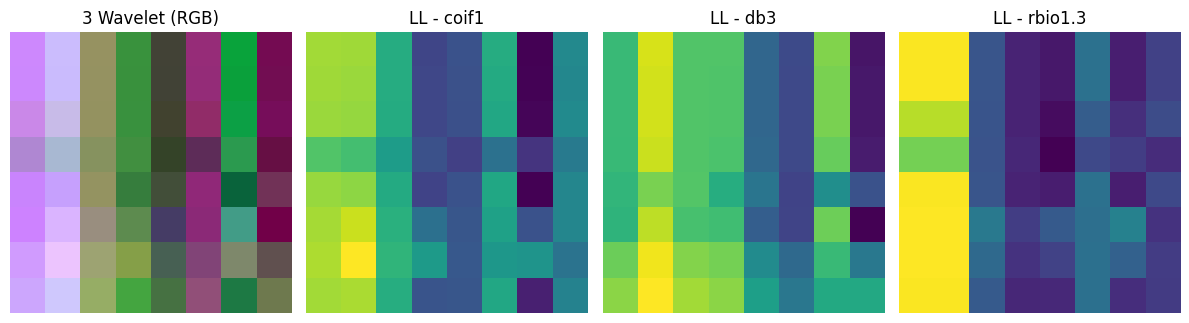

In [56]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

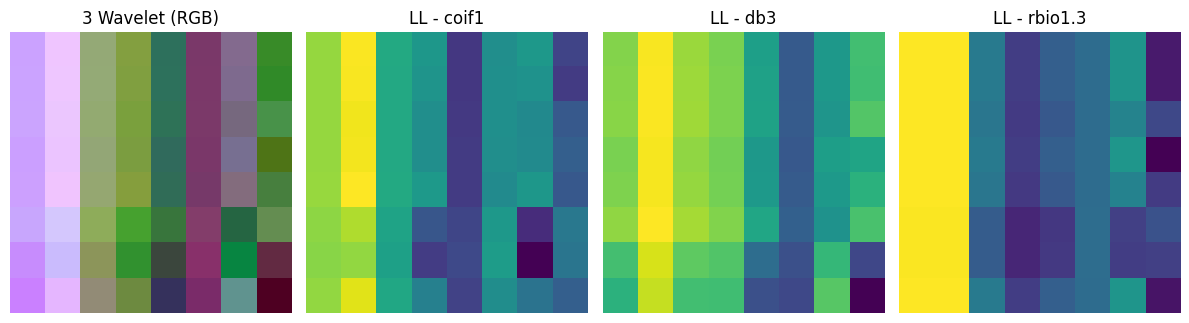

In [57]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_eval_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
print("Channel variance:")
print("coif1:", np.var(X_dwt[:,:, :,0]))
print("db3  :", np.var(X_dwt[:,:, :,1]))
print("rbio :", np.var(X_dwt[:,:, :,2]))


print("Channel variance:")
print("coif1:", np.var(X_eval_dwt[:,:, :,0]))
print("db3  :", np.var(X_eval_dwt[:,:, :,1]))
print("rbio :", np.var(X_eval_dwt[:,:, :,2]))

Channel variance:
coif1: 1.8070785
db3  : 1.118718
rbio : 2.7435324
Channel variance:
coif1: 1.5744803
db3  : 1.1724298
rbio : 2.2634852


In [59]:
print(X_dwt.shape)
print(X_dwt.min(), X_dwt.max())

(13165, 8, 8, 3)
-0.2899621 7.2853637


In [60]:
print(X_eval_dwt.shape)
print(X_eval_dwt.min(), X_eval_dwt.max())

(5642, 8, 8, 3)
-1.2059551 7.999999


In [61]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_train_dwt.npz")
np.savez(OUT_NPZ, X=X_dwt, y=y)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/dwt/tow_ids_train_dwt.npz


In [62]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_eval_dwt.npz")
np.savez(OUT_NPZ, X=X_eval_dwt, y=y_eval)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/dwt/tow_ids_eval_dwt.npz


In [63]:
del X, y, X_dwt, X_eval_dwt, y_eval
gc.collect()

print("Memory cleaned.")

Memory cleaned.


Fokus ke Test

In [64]:
import os
import numpy as np
test_path = os.path.join(Loader, "tow_ids_test_windows_norm.npz")
# load
test_data = np.load(test_path)

X = test_data["X"]
y = test_data["y"]



In [65]:
print("X shape :", X.shape)
print("X dtype :", X.dtype)

print("y shape :", y.shape)
print("y dtype :", y.dtype)

X shape : (12368, 64, 64)
X dtype : float32
y shape : (12368,)
y dtype : int64


In [66]:


N = X.shape[0]

X_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_dwt[i] = dwt_3wavelet_single(X[i], level=level)

print("DWT Done:")
print("Shape:", X_dwt.shape)

DWT Done:
Shape: (12368, 8, 8, 3)


In [67]:
print("\n=== Statistik DWT ===")
print("Min :", X_dwt.min())
print("Max :", X_dwt.max())
print("Mean:", X_dwt.mean())
print("Shape:", X_dwt.shape)


=== Statistik DWT ===
Min : -1.1580839
Max : 7.999999
Mean: 3.3085592
Shape: (12368, 8, 8, 3)


In [68]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_test_dwt.npz")
np.savez(OUT_NPZ, X=X_dwt, y=y)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/dwt/tow_ids_test_dwt.npz


In [69]:
np.random.seed(42)
indices = np.random.choice(N, 5, replace=False)

for idx in indices:
    img = X_dwt[idx]
    label = y[idx]

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

    img_path = os.path.join(SAVE_DIR2, f"sample_{idx}_label_{label}_normalizedtest.png")
    plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
    plt.close()

print("Saved 5 sample images.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.6312775..5.531372].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.32109988..6.054901].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.59971833..6.054901].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.2068925..6.054901].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.48190328..6.054901].


Saved 5 sample images.


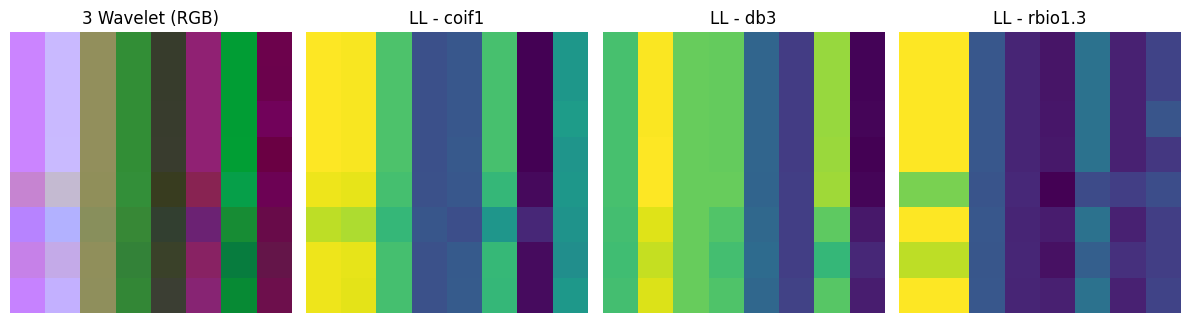

In [70]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
print("Channel variance:")
print("coif1:", np.var(X_dwt[:,:, :,0]))
print("db3  :", np.var(X_dwt[:,:, :,1]))
print("rbio :", np.var(X_dwt[:,:, :,2]))


Channel variance:
coif1: 1.7502342
db3  : 1.1430275
rbio : 2.6366174


In [72]:
del X, y, X_dwt
gc.collect()

print("Memory cleaned.")

Memory cleaned.
